In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# EDA for Email Spam Detection DAtaset

In [2]:
def load_dataset(filepath,column_names=None,seperator=","):
    df=pd.read_csv(filepath,names=column_names,sep=seperator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-"*50)

    print("\n Shape: ",df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())

    print("\nData Types: ")
    print(df.dtypes)

    print("\nMemory information")
    df.info()

    print("First 5 elements")
    print(df.head())

def missing_values(df):
    missing=df.isnull().sum()
    percent=(missing/len(df) )*100

    result=pd.DataFrame(
    {"missing":missing,
    "percent":percent
    })

    print(result)

    if (missing.sum() ==0):
        print("There is no missing value!")
    else:
        print("Missing Values detected")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ",duplicates);

    if(duplicates ==0):
        print("No duplicates detected!")
    else:
        print("Duplicates are detected")

    return duplicates

def summary_statistics(df):
    print("\nSummary statsitics")
    print(df.describe())

   

In [3]:
def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    plt.show()

    return counts
def plot_histogram(df,bins=10):
    numeric_df=df.select_dtypes("number")

    numeric_df.hist(bins=bins)
    plt.suptitle("Histogram of numerical features")
    plt.tight_layout()
    plt.show()

def plot_boxplot(df):
    numeric_df = df.select_dtypes("number")

    for col in numeric_df.columns:
        plt.boxplot(numeric_df[col])
        plt.title("BoxPlot of "+str(col))
        plt.show()
def plot_heatmap(df):
    numeric_df = df.select_dtypes("number")
    corr = numeric_df.corr()
    sns.heatmap(corr,annot=True)
    plt.title("Heatmap !")
    plt.show()

def plot_scatterplot(df,target_column=None):

    if (target_column is not None):
        sns.pairplot(df,hue=target_column)
    else:
        sns.pairplot(df)
    plt.suptitle("Pairplot")
    plt.tight_layout()
    plt.show()

In [4]:
def perform_eda(
    filepath,
    target_column=None,
    categorical_columns=None,
    pairplot_columns=None,
    column_names=None,
    separator=",",

    show_histogram=True,
    show_boxplot=True,
    show_heatmap=True,
    show_pairplot=True
):

    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)


    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)


    if show_histogram:
        plot_histogram(df)

    if show_boxplot:
        plot_boxplot(df)

    if show_heatmap:
        plot_heatmap(df)

    if show_pairplot:

        if pairplot_columns is not None:

            if target_column is not None:
                plot_scatterplot(
                    df[pairplot_columns + [target_column]],
                    target_column
                )

            else:
                plot_scatterplot(
                    df[pairplot_columns]
                )

        else:
            print("\nPairplot skipped (No columns specified).")

    return df


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (4601, 58)

Columns: 
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_p

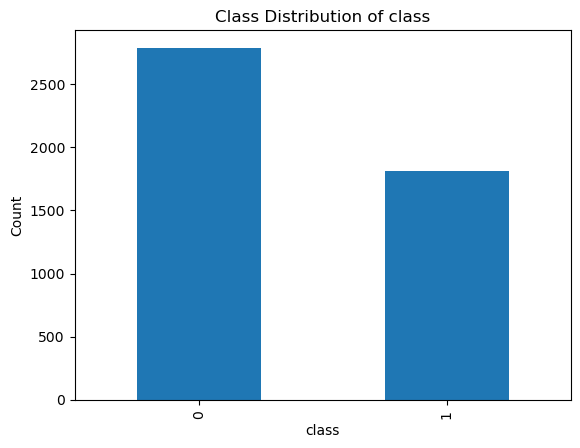

In [5]:
df=perform_eda("spamEmail/spambase_csv.csv",show_histogram=False,show_boxplot=False,show_heatmap=False,
            show_pairplot=False,categorical_columns=["class"])

## Perform KNN On dataset 

### Steps to be done
1. Load the spam and ham emails
2. Remove common punctuation and symbols
3. Lowercase all letters
4. Remove stopwords (very common words like pronouns, articles, etc.)
5. Split emails into training email and testing emails
6. For each test email, calculate the similarity between it and all training emails
    6.1. For each word that exists in either test email or training email, count its frequency in both emails
    6.2. calculate the euclidean distance between both emails to determine similarity
7. Sort the emails in ascending order of euclidean distance
8. Select the k nearest neighbors (shortest distance)
9. Assign the class which is most frequent in the selected k nearest neighbours to the new email

- Remove Email No.
- Separate features (X) and target (Y)
- Split into training and testing sets
- Scale X_train and X_test
- Choose a value for k
- Train the KNN classifier using the training data.
- Predict the labels for the test data.
- Evaluate the predictions (accuracy, confusion matrix, precision, recall, etc.).

**NOTE:** The Dataset already has some preprocessed and each email is in a row with word in each column and has target column
prediction(0=Ham.1=Spam). So we can move to step 5

## Stuff to do now
1. Remove the Email No. column.
2. Separate the features (word-frequency columns) and the target (Prediction).
3. Split the data into training and testing sets.

In [6]:
# email=df.drop(columns=["Email No."])  

'''
Seperating features and target
'''

X = df.drop(columns=["class"]) #Features
Y= df["class"]


In [7]:
# Train , test splitting
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,
                                               random_state=42,stratify=Y)


## Standardize and evaluate knn for different value of k

In [8]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_standard=scaler.fit_transform(x_train)
x_test_standard=scaler.transform(x_test)


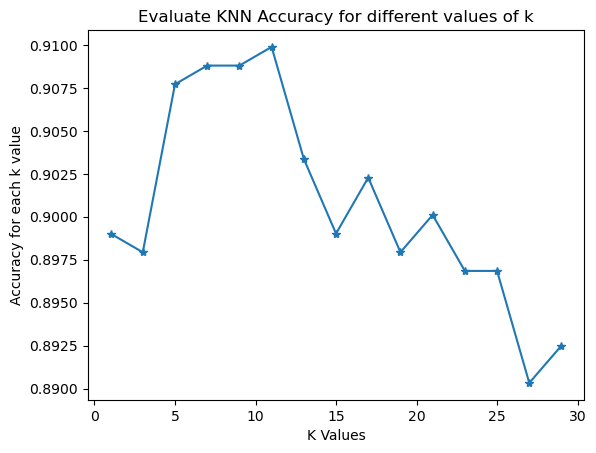

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
accuracy = []

for k in range(1,31,2):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_standard,y_train)

    y_pred=knn.predict(x_test_standard)
    accuracy.append( accuracy_score(y_test,y_pred))

# print(accuracy)

plt.plot(range(1,31,2),accuracy,marker="*")
plt.xlabel("K Values")
plt.ylabel("Accuracy for each k value")
plt.title("Evaluate KNN Accuracy for different values of k")
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"{'k':<5}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")

for k in [1,3,5,7,9,11]:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_standard, y_train)

    y_pred = knn.predict(x_test_standard)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"{k:<5}{acc:<12.3f}{prec:<12.3f}{rec:<12.3f}{f1:<12.3f}")

k    Accuracy    Precision   Recall      F1          
1    0.899       0.895       0.893       0.894       
3    0.898       0.893       0.893       0.893       
5    0.908       0.904       0.903       0.903       
7    0.909       0.906       0.903       0.904       
9    0.909       0.906       0.903       0.904       
11   0.910       0.908       0.903       0.905       


# 2. Gaussian Naive Bayes

- Using standardized feature (x_train_standard,x_test_standard)
- And target variable(y_train,y_test)

In [11]:
from sklearn.naive_bayes import GaussianNB
gaussianNB=GaussianNB()
gaussianNB.fit(x_train_standard,y_train)

y_predGaussian = gaussianNB.predict(x_test_standard)


In [12]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score

print("Accuracy: ",accuracy_score(y_test,y_predGaussian) ) #actual,pred
print(confusion_matrix(y_test,y_predGaussian))
print(classification_report(y_test,y_predGaussian))

y_prob = gaussianNB.predict_proba(x_test_standard)[:, 1]
print("ROC AUC: ",roc_auc_score(y_test,y_prob))


Accuracy:  0.8327904451682954
[[419 139]
 [ 15 348]]
              precision    recall  f1-score   support

           0       0.97      0.75      0.84       558
           1       0.71      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.83       921

ROC AUC:  0.9376116986087661


# 3.Multinomial Naive Bayes
- Not using Standard Scaler
- Using minmax scaler

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

x_train_minmax=scaler.fit_transform(x_train)
x_test_minmax=scaler.transform(x_test)

In [14]:
from sklearn.naive_bayes import MultinomialNB

multinomial_nb= MultinomialNB()
multinomial_nb.fit(x_train_minmax,y_train)
y_predMultinomial= multinomial_nb.predict(x_test_minmax)

In [15]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score 

print("ACCURACY: ",accuracy_score(y_test,y_predMultinomial))
print(confusion_matrix(y_test,y_predMultinomial))
print(classification_report(y_test,y_predMultinomial))

y_prob=multinomial_nb.predict_proba(x_test_minmax)[:,1]
print("ROC AUC SCORE: ",roc_auc_score(y_test,y_prob))

ACCURACY:  0.8957654723127035
[[538  20]
 [ 76 287]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       558
           1       0.93      0.79      0.86       363

    accuracy                           0.90       921
   macro avg       0.91      0.88      0.89       921
weighted avg       0.90      0.90      0.89       921

ROC AUC SCORE:  0.9611905960879568


# 4. Bernoulli Naive Bayes
- No need for preprocessing!

In [16]:
from sklearn.naive_bayes import BernoulliNB
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(x_train_minmax,y_train)

y_predBernoulli = bernoulli_nb.predict(x_test_minmax)

In [17]:
print("Accuracy: ",accuracy_score(y_test,y_predBernoulli))
print(confusion_matrix(y_test,y_predBernoulli))
print(classification_report(y_test,y_predBernoulli))

y_prob=bernoulli_nb.predict_proba(x_test_minmax)[:,1]
print("ROC AUC: ",roc_auc_score(y_test,y_prob))

Accuracy:  0.8794788273615635
[[513  45]
 [ 66 297]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       558
           1       0.87      0.82      0.84       363

    accuracy                           0.88       921
   macro avg       0.88      0.87      0.87       921
weighted avg       0.88      0.88      0.88       921

ROC AUC:  0.9456737462602566


# **Tuning KNN using GRIDSearch CV** 

In [18]:
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
param_grid = {
    "n_neighbors":[1,3,5,7,9,11,13,15],
    "metric":["euclidean","manhattan"],
    "weights":["uniform","distance"]
}
grid = GridSearchCV(
estimator=knn,
param_grid=param_grid,
cv=5,
scoring="accuracy"
)

start=time.time()
grid.fit(x_train_standard, y_train)
grid_time=time.time() - start
print("\nGridSearch time: ",grid_time,"\n")

print("++++++ RESULTS +++++++")

print("Best parameter")
print(grid.best_params_)
print("BEst accuracy score")
print(grid.best_score_)
print("")
best_knn=grid.best_estimator_
y_pred = best_knn.predict(x_test_standard)




GridSearch time:  1.8605973720550537 

++++++ RESULTS +++++++
Best parameter
{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
BEst accuracy score
0.9228260869565217



In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9218241042345277
[[540  18]
 [ 54 309]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       558
           1       0.94      0.85      0.90       363

    accuracy                           0.92       921
   macro avg       0.93      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



# Tuning KNN using RandomizedSearchCV

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn= KNeighborsClassifier()
param_dist = {  #nneighbor,metric,weights
    "n_neighbors":[1,3,5,7,9,11,13,15],
    "metric":["euclidean","manhattan"],
    "weights":["uniform","distance"]
}

randomSearch=RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42
)

start=time.time()
randomSearch.fit(x_train_standard,y_train)
random_time = time.time() - start
print("RandomizedSearch Time: ",random_time)

RandomizedSearch Time:  0.6521468162536621


In [21]:
print("        RESULTS         ")
print("Best Parameters: ")
print(randomSearch.best_params_)

print("\nBest CV Accuracy: ")
print(randomSearch.best_score_)

# choosing model with best one
best_knn_random=randomSearch.best_estimator_
y_pred=best_knn_random.predict(x_test_standard)

print("Test Accurac: ",accuracy_score(y_test,y_pred))
print("\nThe confusion matrix \n",confusion_matrix(y_test,y_pred))
print("\nThe classification report is \n",classification_report(y_test,y_pred))


        RESULTS         
Best Parameters: 
{'weights': 'distance', 'n_neighbors': 13, 'metric': 'manhattan'}

Best CV Accuracy: 
0.9214673913043476
Test Accurac:  0.9163952225841476

The confusion matrix 
 [[540  18]
 [ 59 304]]

The classification report is 
               precision    recall  f1-score   support

           0       0.90      0.97      0.93       558
           1       0.94      0.84      0.89       363

    accuracy                           0.92       921
   macro avg       0.92      0.90      0.91       921
weighted avg       0.92      0.92      0.92       921



# Comparison of KDTree and BallTree
It is where data is organied such that nearest neighbor searches are faster.

In [22]:
k=9
metric="manhattan"
weights="distance"


## KD Tree

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_kd = KNeighborsClassifier (
    n_neighbors = 9,
    metric=metric,
    weights=weights,
    algorithm="kd_tree"
)

# Training Time
start=time.time()
knn_kd.fit(x_train_standard,y_train)
knn_kd_train=time.time()-start

# Testing Timr
start=time.time()
y_pred_kd = knn_kd.predict(x_test_standard)
knn_kd_test=time.time()-start

## BallTree

In [31]:
knn_ball = KNeighborsClassifier(
    n_neighbors = 9,
    metric="manhattan",
    weights=weights,
    algorithm="ball_tree"
)

# Training Tiime
start=time.time()
knn_ball.fit(x_train_standard,y_train)
knn_ball_train = time.time()-start

# Testing time
start= time.time()
y_pred_ball= knn_ball.predict(x_test_standard)
knn_ball_test = time.time()-start

In [34]:
from sklearn.metrics import accuracy_score

print("KDTree Accuracy:",accuracy_score(y_test,y_pred_kd))
print("BallTree Accuracy: ",accuracy_score(y_test,y_pred_ball))

print("KDTree Train: ",knn_kd_train)
print("Ball Tree Train: ",knn_ball_train)

print("KDTree Test: ",knn_kd_test)
print("Ball Tree Test: ",knn_ball_test)

KDTree Accuracy: 0.9207383279044516
BallTree Accuracy:  0.9207383279044516
KDTree Train:  0.013062238693237305
Ball Tree Train:  0.006426095962524414
KDTree Test:  0.0994570255279541
Ball Tree Test:  0.08060908317565918


# 5 Fold Cross Validation

## (i). model definition
- map each classifier to its scaled dataser

In [36]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold,cross_validate
from sklearn.metrics import confusion_matrix,roc_curve,auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB, BernoulliNB

models = {
    "KNN (k=11)": (KNeighborsClassifier(n_neighbors=11),x_train_standard,x_test_standard),
    "Gaussian NB":(GaussianNB(),x_train_standard,x_test_standard),
    "Multinomial NB":(MultinomialNB(),x_train_minmax,x_test_minmax),
    "Bernoulli NB":(BernoulliNB(),x_train_minmax,x_test_minmax)

}

Kf=KFold(n_splits=5,shuffle=True,random_state=42)

## (ii) 5-Fold Cross Validation and Timing Metric
- executes cross validation across all models to assess their generalized accuracy
without risk of overfitting

In [44]:
print(f"{'Model':<20}|{'Mean CV':<15}|{'Train Time':<18}|{'Predict Time':<18}")

for name,(model,xTrainScaled,_) in models.items():
    cv_results = cross_validate(
        model,xTrainScaled,y_train,
        cv=Kf,scoring='accuracy',return_train_score=False
    )

    mean_accuracy=cv_results['test_score'].mean()
    mean_fit_time = cv_results['fit_time'].mean()
    mean_score_time = cv_results["score_time"].mean()

    print(f"{name:<20}|{mean_accuracy:<15.4}|{mean_fit_time:<18.4}|{mean_score_time:<18.4}")

Model               |Mean CV        |Train Time        |Predict Time      
KNN (k=11)          |0.8986         |0.0008678         |0.006259          
Gaussian NB         |0.8149         |0.001437          |0.0006123         
Multinomial NB      |0.8929         |0.001154          |0.000633          
Bernoulli NB        |0.8883         |0.002031          |0.0008618         


## (iii) Confusion Matrix Evaluation

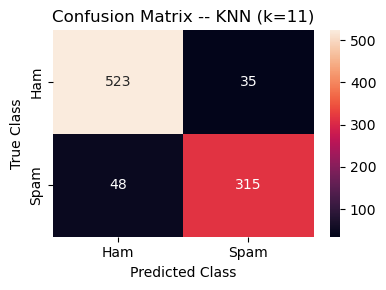

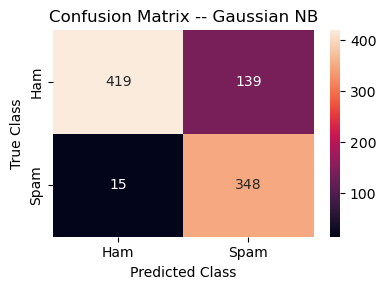

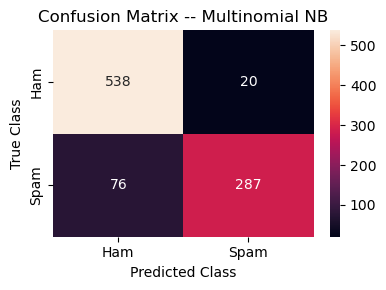

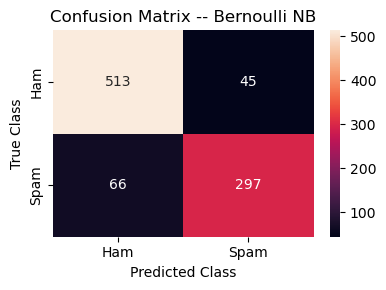

In [51]:
for name,(model,xTrainScaled,xTestScaled) in models.items():
    model.fit(xTrainScaled,y_train)
    y_pred=model.predict(xTestScaled)

    cm=confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm,annot=True,fmt='d',
    xticklabels=['Ham','Spam'],yticklabels=['Ham','Spam'])
    plt.title(f"Confusion Matrix -- {name}")
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.tight_layout()
    plt.show()

# (iv) Multi - Model ROC Curve COmparison
- extract prediction probabilities from each trained model to compute
teir true positve and false positive rate
- overlay all of their roc curves

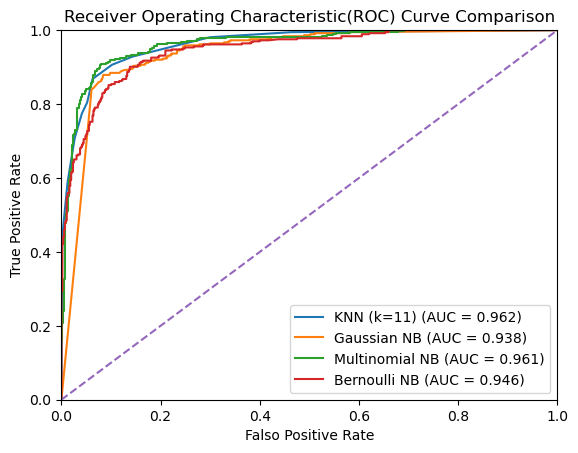

In [64]:
for name,(model,xTrainScaled,xTestScaled) in models.items():
    model.fit(xTrainScaled,y_train)
    y_probs = model.predict_proba(xTestScaled)[:,1]
    fpr,tpr,_ = roc_curve(y_test,y_probs)
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],linestyle="--")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("Falso Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic(ROC) Curve Comparison")
plt.legend()
plt.show()